# Parent-child repertoire decay

How fast does binding function change along a branch?

Every parent-child edge of the human tree — 864 of them, joining ancestors to
ancestors and ancestors to extant receptors — is scored by how much of the parent's
ligand repertoire the child retains, against the branch length separating them.

In [1]:
import sys
sys.path.append("../../scripts")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal, fisher_exact

from matplotlib.colors import ListedColormap, to_rgb
from matplotlib.patches import Patch
from plotting_functions import custom_plots, FIGSIZE
from ancestral_sets import load_ancestral, functional_groups, descriptors, odor_tags, \
                           decay_table, edge_table, node_topology, node_sets, \
                           save_fig, save_table, \
                           FG_SMARTS, DESCRIPTORS, PATTERN_ORDER, PATTERN_LABELS, TEN_NODES
plt.rcParams.update(custom_plots())

COMMON_COL, CLASS1_COL, CLASS2_COL = "#5F6A72", "#7f1734", "#557c99"
NODE_COL = {"common_ancestor": COMMON_COL, "class1_ancestor": CLASS1_COL, "class2_ancestor": CLASS2_COL}

anc = load_ancestral()
print(f"mode           : {anc.mode}")
print(f"ancestral cut  : median probability > {list(anc.per_node_cut.values())[0]:.2f}")
for node in anc.per_node_cut:
    print(f"  {node:<18} {int(anc.node_presence[node].sum())} ligands")
print(f"\nligands active in at least one node: {len(anc.all_smiles)}")

mode           : density
ancestral cut  : median probability > 0.89
  common_ancestor    21 ligands
  class1_ancestor    21 ligands
  class2_ancestor    8 ligands

ligands active in at least one node: 39


## Edges

In [2]:
edges = edge_table()           # None default = shared density fill
print(f"{len(edges)} edges  " + str(edges.kind.value_counts().to_dict()))
print(edges[["similarity", "weighted", "retention", "gained", "lost", "branch_len"]]
      .describe().round(3).to_string())
save_table(edges, "04_edge_table")

861 edges  {'ancestor': 431, 'extant': 430}
       similarity  weighted  retention   gained     lost  branch_len
count     861.000   861.000    858.000  861.000  861.000     861.000
mean        0.487     0.580      0.655    9.447    7.620       0.237
std         0.295     0.221      0.326   37.424   21.122       0.228
min         0.000     0.045      0.000    0.000    0.000       0.000
25%         0.250     0.416      0.400    0.000    0.000       0.064
50%         0.500     0.612      0.722    1.000    2.000       0.150
75%         0.690     0.762      1.000    5.000    6.000       0.355
max         1.000     1.000      1.000  532.000  321.000       1.382


## Similarity against branch length

Binary Jaccard between parent and child repertoires, against the child's branch
length.

In [3]:
from scipy.stats import pearsonr, spearmanr

x, y = edges.branch_len.to_numpy(), edges.similarity.to_numpy()
r_p, p_p = pearsonr(x, y)
r_s, p_s = spearmanr(x, y)
print(f"Pearson  r = {r_p:+.3f}  p = {p_p:.2e}")
print(f"Spearman r = {r_s:+.3f}  p = {p_s:.2e}")

edges["tertile"] = pd.qcut(edges.branch_len, 3, labels=["short", "mid", "long"])
print("\n" + edges.groupby("tertile", observed=True)["similarity"]
      .agg(["size", "median"]).round(3).to_string())

Pearson  r = -0.404  p = 4.72e-35
Spearman r = -0.455  p = 3.64e-45

         size  median
tertile              
short     287   0.667
mid       287   0.500
long      287   0.281


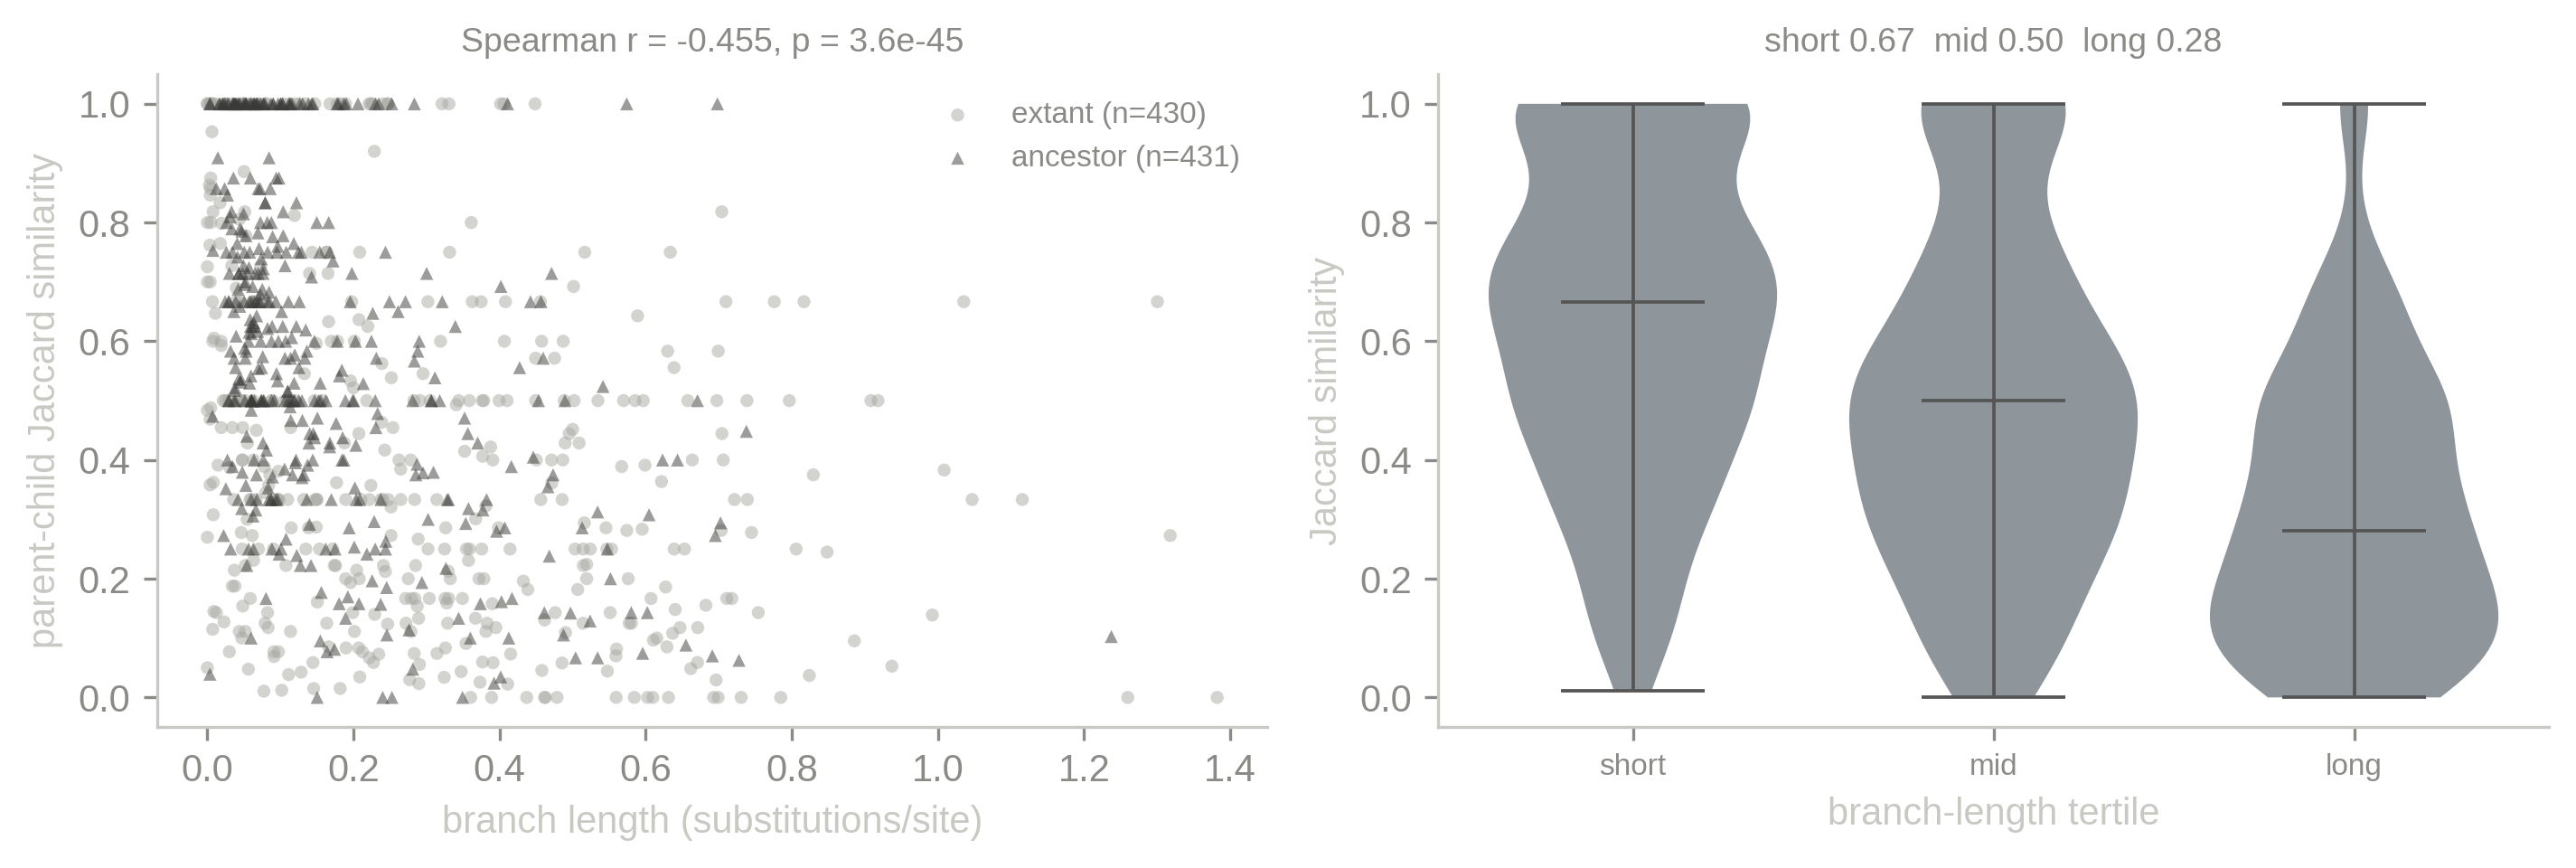

In [4]:
# Neutral greys, deliberately NOT the Class I/II palette: on these panels the split is
# ancestor vs extant, not receptor class, and reusing the class colours here read as a
# class contrast. The two groups are told apart by marker shape (triangle vs circle).
ANC_COL, EXT_COL = "#3a3a38", "#a8a8a3"

fig, axes = plt.subplots(1, 2, figsize=(FIGSIZE[0] * 2.4, FIGSIZE[1] * 1.1))

ax = axes[0]
for kind, colr, mk in [("extant", EXT_COL, "o"), ("ancestor", ANC_COL, "^")]:
    sub = edges[edges.kind == kind]
    ax.scatter(sub.branch_len, sub.similarity, s=12, alpha=0.5, color=colr,
               marker=mk, edgecolor="none", label=f"{kind} (n={len(sub)})")
ax.set_xlabel("branch length (substitutions/site)")
ax.set_ylabel("parent-child Jaccard similarity")
ax.set_title(f"Spearman r = {r_s:+.3f}, p = {p_s:.1e}", fontsize=9)
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
data = [edges.loc[edges.tertile == t, "similarity"].values for t in ["short", "mid", "long"]]
parts = ax.violinplot(data, showmedians=True, widths=0.8)
for pc in parts["bodies"]:
    pc.set_facecolor("#5F6A72"); pc.set_alpha(0.7); pc.set_edgecolor("none")
for key in ["cmedians", "cmaxes", "cmins", "cbars"]:
    parts[key].set_color("#555"); parts[key].set_linewidth(0.9)
ax.set_xticks([1, 2, 3]); ax.set_xticklabels(["short", "mid", "long"], fontsize=8)
ax.set_ylabel("Jaccard similarity"); ax.set_xlabel("branch-length tertile")
ax.set_title("  ".join(f"{t} {np.median(d):.2f}" for t, d in zip(["short","mid","long"], data)), fontsize=9)
plt.tight_layout(); save_fig(fig, "04_similarity_vs_branch"); plt.show()

## Exponential decay and functional half-life

Fitting `similarity = a·exp(-b·d) + c` gives the divergence at which half the
retainable overlap is gone.

a = 0.456 +/- 0.034
b = 4.283 +/- 0.927
c = 0.260 +/- 0.036   (asymptote)
R2 = 0.205   n edges = 861

functional half-life = 0.162 +/- 0.035 substitutions/site


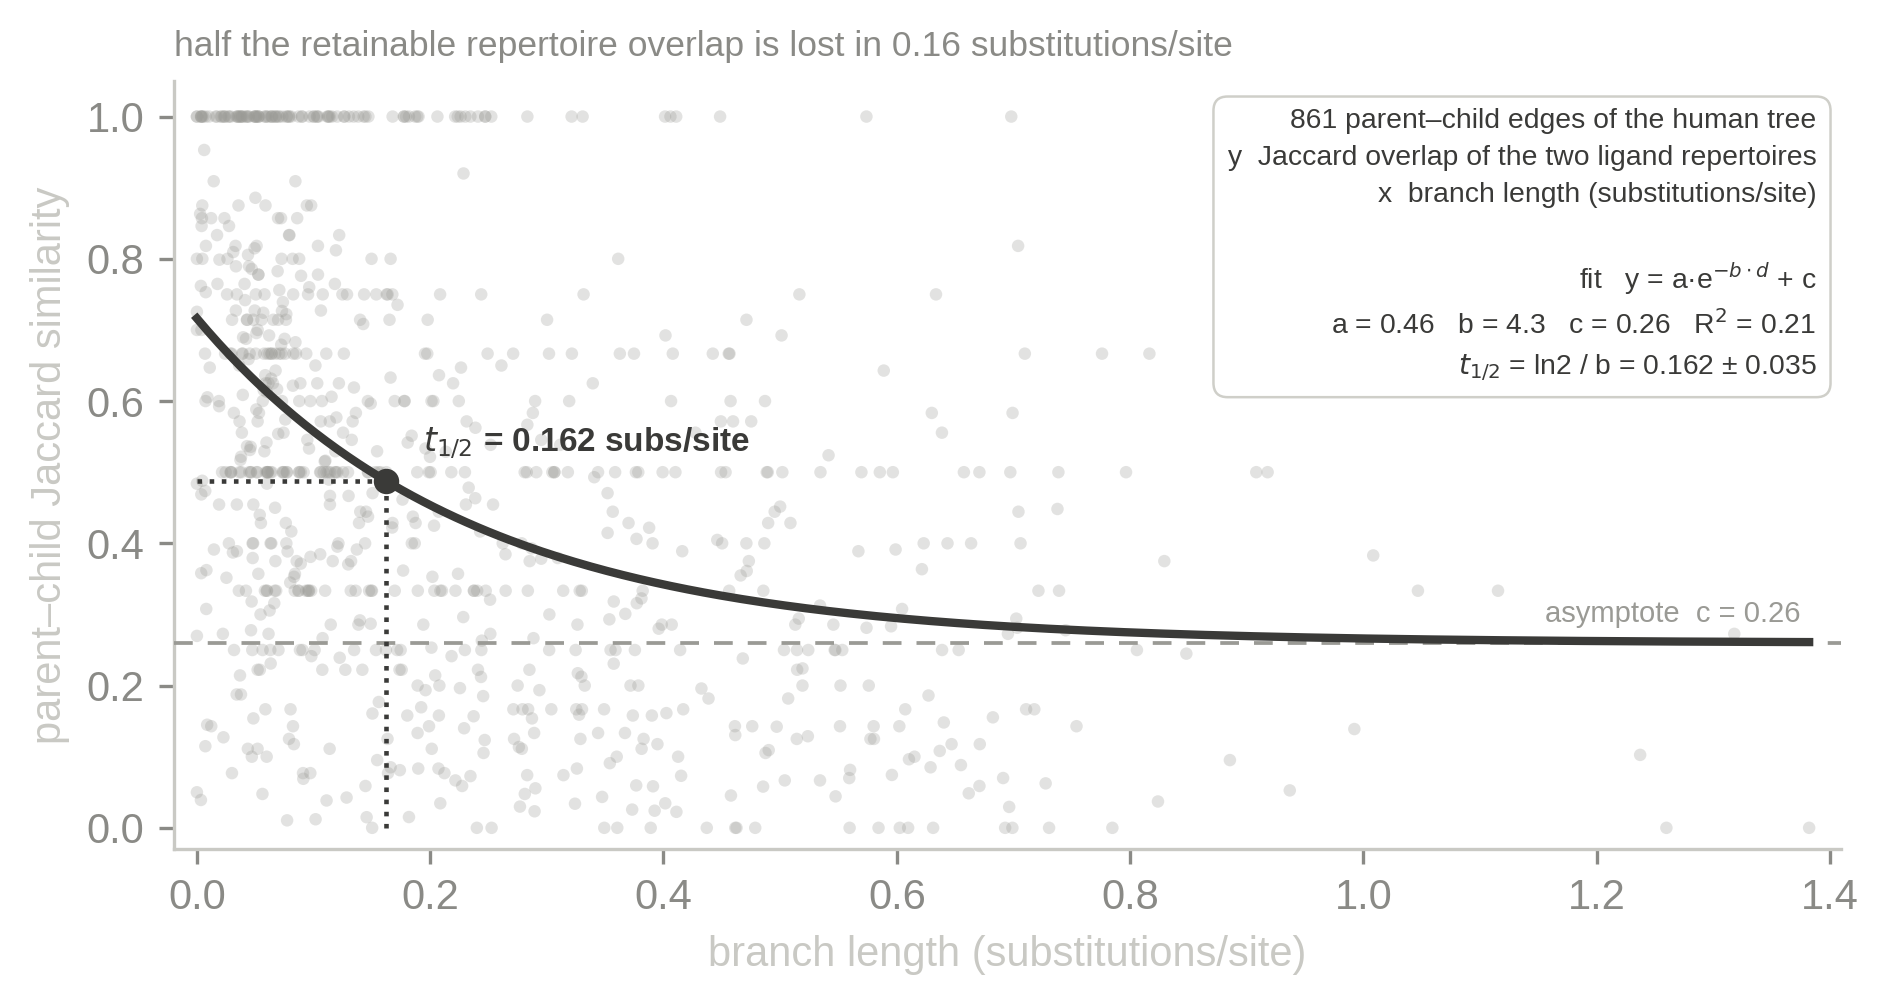

In [5]:
from scipy.optimize import curve_fit

def exp_decay(d, a, b, c):
    return a * np.exp(-b * d) + c

popt, pcov = curve_fit(exp_decay, x, y, p0=[0.5, 5.0, 0.3],
                       bounds=([0, 0, 0], [1.5, 1e3, 1.0]))
a, b, c = popt
err = np.sqrt(np.diag(pcov))
half_life = np.log(2) / b
half_err = np.log(2) * err[1] / b ** 2
resid = y - exp_decay(x, *popt)
r2 = 1 - resid.var() / y.var()

print(f"a = {a:.3f} +/- {err[0]:.3f}")
print(f"b = {b:.3f} +/- {err[1]:.3f}")
print(f"c = {c:.3f} +/- {err[2]:.3f}   (asymptote)")
print(f"R2 = {r2:.3f}   n edges = {len(x)}")
print(f"\nfunctional half-life = {half_life:.3f} +/- {half_err:.3f} substitutions/site")

# Deliberately monochrome. Crimson and blue are the Class I / Class II colours everywhere
# else in the figure, and nothing here is class-resolved -- every parent-child edge of the
# tree is pooled -- so using them would imply a split that this panel does not make.
INK, MID, PALE = "#3a3a38", "#9a9a95", "#cfcfc9"

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.6, FIGSIZE[1] * 1.15))
ax.scatter(x, y, s=9, alpha=0.28, color=MID, edgecolor="none", zorder=2)

xs = np.linspace(x.min(), x.max(), 300)
ax.plot(xs, exp_decay(xs, *popt), color=INK, lw=2.0, zorder=4)

# asymptote: the overlap that never decays away
ax.axhline(c, color=MID, ls=(0, (5, 4)), lw=0.9, zorder=3)
ax.annotate(f"asymptote  c = {c:.2f}", xy=(x.max(), c), xytext=(-2, 5),
            textcoords="offset points", fontsize=7, color=MID, ha="right")

# half-life: where half the decaying part of the overlap is gone
y_half = c + a / 2
ax.plot([half_life, half_life], [0, y_half], color=INK, ls=":", lw=1.1, zorder=3)
ax.plot([0, half_life], [y_half, y_half], color=INK, ls=":", lw=1.1, zorder=3)
ax.scatter([half_life], [y_half], s=26, color=INK, zorder=5)
ax.annotate(f"$t_{{1/2}}$ = {half_life:.3f} subs/site",
            xy=(half_life, y_half), xytext=(9, 7), textcoords="offset points",
            fontsize=8, color=INK, fontweight="bold")

info = (f"{len(x)} parent\u2013child edges of the human tree\n"
        f"y  Jaccard overlap of the two ligand repertoires\n"
        f"x  branch length (substitutions/site)\n\n"
        f"fit   y = a\u00b7e$^{{-b\cdot d}}$ + c\n"
        f"a = {a:.2f}   b = {b:.1f}   c = {c:.2f}   R$^2$ = {r2:.2f}\n"
        f"$t_{{1/2}}$ = ln2 / b = {half_life:.3f} \u00b1 {half_err:.3f}")
ax.text(0.985, 0.965, info, transform=ax.transAxes, ha="right", va="top",
        fontsize=6.8, color=INK, linespacing=1.55,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor=PALE, linewidth=0.6))

ax.set_xlabel("branch length (substitutions/site)")
ax.set_ylabel("parent\u2013child Jaccard similarity")
ax.set_title("half the retainable repertoire overlap is lost in "
             f"{half_life:.2f} substitutions/site", fontsize=8.5, loc="left")
ax.set_ylim(-0.03, 1.05)
ax.set_xlim(-0.02, x.max() * 1.02)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout(); save_fig(fig, "04_functional_half_life"); plt.show()


## Is the binarisation driving this?

The cut is an output rather than a choice now, but these three checks still earn their place.

**Weighted Jaccard** runs on the raw probabilities and never binarises, so a ligand drifting
from 0.51 to 0.49 costs it almost nothing while it costs the binary version a whole ligand.

**Sweeping the cut** shows whether the answer depends on where the line falls.

**Splitting by child type** addresses the other story: that longer branches give worse
reconstructions and an apparent loss of overlap with no real change in function. The 433
extant children carry no reconstruction uncertainty at all.

In [6]:
rho, pv = spearmanr(edges.similarity, edges.weighted)
rw, pw = spearmanr(edges.branch_len, edges.weighted)
print(f"binary vs weighted Jaccard   Spearman r = {rho:+.3f}  p = {pv:.2e}")
print(f"weighted vs branch length    Spearman r = {rw:+.3f}  p = {pw:.2e}")

sweep = []
for t in [None, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.915]:   # None = the density fill actually used
    s = edge_table(threshold=t)
    fit, _ = curve_fit(exp_decay, s.branch_len, s.similarity, p0=[0.5, 5.0, 0.3],
                       bounds=([0, 0, 0], [1.5, 1e3, 1.0]))
    sweep.append({"cut": "density" if t is None else f"{t:.3f}", "edges": len(s),
                  "spearman": round(spearmanr(s.branch_len, s.similarity).statistic, 3),
                  "half_life": round(np.log(2) / fit[1], 3)})
sweep = pd.DataFrame(sweep)
print("\n" + sweep.to_string(index=False))
save_table(sweep, "04_threshold_sweep")

print()
for kind in ["extant", "ancestor"]:
    s = edges[edges.kind == kind]
    rb = spearmanr(s.branch_len, s.similarity)
    rww = spearmanr(s.branch_len, s.weighted)
    print(f"{kind:9s} n={len(s):3d}  binary r={rb.statistic:+.3f} p={rb.pvalue:.1e}"
          f"   weighted r={rww.statistic:+.3f} p={rww.pvalue:.1e}")

binary vs weighted Jaccard   Spearman r = +0.694  p = 8.77e-125
weighted vs branch length    Spearman r = -0.582  p = 3.43e-79

    cut  edges  spearman  half_life
density    861    -0.455      0.162
  0.300    864    -0.534      0.135
  0.400    864    -0.542      0.133
  0.500    864    -0.542      0.135
  0.600    864    -0.547      0.139
  0.700    864    -0.550      0.140
  0.800    864    -0.524      0.151
  0.915    806    -0.348      0.141

extant    n=430  binary r=-0.328 p=3.1e-12   weighted r=-0.452 p=5.4e-23
ancestor  n=431  binary r=-0.470 p=4.7e-25   weighted r=-0.605 p=2.4e-44


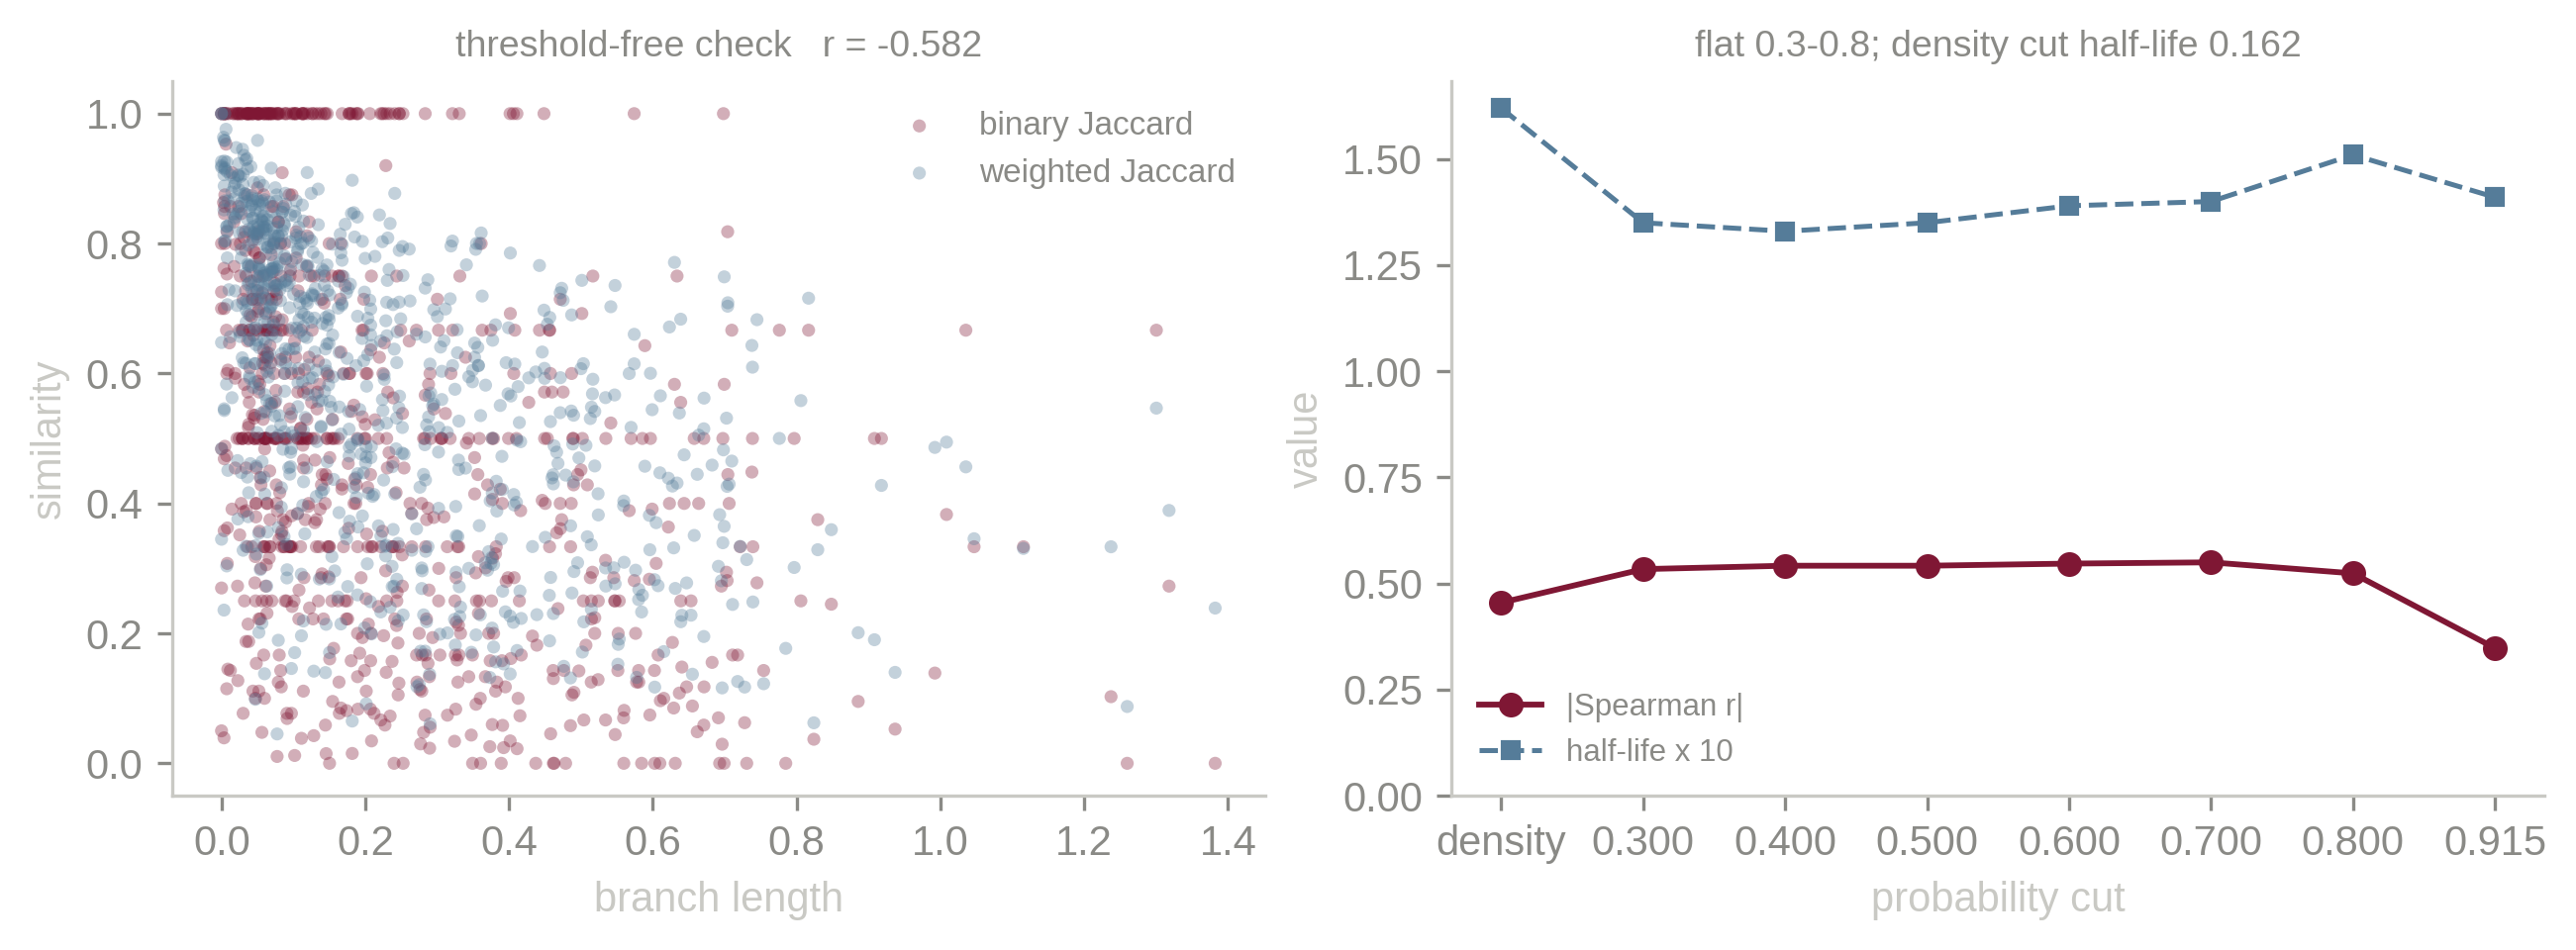

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(FIGSIZE[0] * 2.2, FIGSIZE[1] * 1.1))

ax = axes[0]
ax.scatter(edges.branch_len, edges.similarity, s=10, alpha=0.35,
           color="#7f1734", edgecolor="none", label="binary Jaccard")
ax.scatter(edges.branch_len, edges.weighted, s=10, alpha=0.35,
           color="#557c99", edgecolor="none", label="weighted Jaccard")
ax.set_xlabel("branch length"); ax.set_ylabel("similarity")
ax.legend(frameon=False, fontsize=8)
ax.set_title(f"threshold-free check   r = {rw:+.3f}", fontsize=9)

ax = axes[1]
ax.plot(sweep.cut, -sweep.spearman, "o-", color="#7f1734", lw=1.4, ms=5, label="|Spearman r|")
ax.plot(sweep.cut, sweep.half_life * 10, "s--", color="#557c99", lw=1.2, ms=4,
        label="half-life x 10")
ax.set_xlabel("probability cut"); ax.set_ylabel("value")
ax.set_ylim(0, None); ax.legend(frameon=False, fontsize=7.5)
_d = sweep[sweep.cut == "density"].iloc[0]
ax.set_title(f"flat 0.3-0.8; density cut half-life {_d.half_life:.3f}", fontsize=9)
plt.tight_layout(); save_fig(fig, "04_threshold_check"); plt.show()